# Autograd - Demonstration

## Introduction

After doing many differnt machine learning projects I decided I wanted a deeper understanding of the maths and algarithems behind librarys such as pytorch, starting from the ground up. autograd.main is a library of functions and classes making up all the building blocks for a classification model (see the MNIST demo bellow) build using **only** NumPy. Each component is demonstrated brefily bellow, however if you want to take a closer look go to the main file where the componets are all well documented and the code fairly readable.

Towards the end of this notebook a full gradient decent loop is shown before a model already trained on the MNIST dataset is loaded, again trained exclusively using this library.

**Full disclosure**:
As someone who taught themself how to code, I have used Ai tools such as Gemini and ChatGPT to explian errors, help with syntax and spot any bugs I may have missed. However, I made sure not to blindly use their code and **no** function was ever desined or fully created by anyone or anything other than myself.

## Library componets

In [ ]:
import numpy as np
import main

In [2]:
# These test inputs will be used throughout this notebook.
test_inputs = [
    np.array([-1, -0.5, 0, 1, 63.4]),
    [[0, 1, 2], [2, 0.7, -1]],
    (-2, -0.32, 0, 1, 0),
    "This is a string."
]

test_input_targets = [
    np.array([-3, -0.1, 0, 1, 1]),
    [[0, 1, 2], [3, 0.6, -1.1]],
    (2, -0.2, 5.6, 3, 2),
    "This is not a string."
]

In [3]:
# ReLU
for t in test_inputs:
    try:
        print(f"Input - {t} - Output - {main.ReLU(t)}")
    except:
        print(f"Input - {t} - can not be passed through ReLU.")

Input - [-1.  -0.5  0.   1.  63.4] - Output - [ 0.   0.   0.   1.  63.4]
Input - [[0, 1, 2], [2, 0.7, -1]] - Output - [[0.  1.  2. ]
 [2.  0.7 0. ]]
Input - (-2, -0.32, 0, 1, 0) - Output - [0. 0. 0. 1. 0.]
Input - This is a string. - can not be passed through ReLU.


In [4]:
# backwards_ReLU (the derivative of ReLU)
for t in test_inputs:
    try:
        print(f"Input - {t} - Output - {main.backwards_ReLU(t)}")
    except:
        print(f"Input - {t} - can not be passed through backwards_ReLU.")

Input - [-1.  -0.5  0.   1.  63.4] - Output - [0. 0. 0. 1. 1.]
Input - [[0, 1, 2], [2, 0.7, -1]] - Output - [[0. 1. 1.]
 [1. 1. 0.]]
Input - (-2, -0.32, 0, 1, 0) - Output - [0. 0. 0. 1. 0.]
Input - This is a string. - can not be passed through backwards_ReLU.


In [5]:
# Softmax
for t in test_inputs:
    try:
        print(f"Input - {t} - Output - {main.Softmax(t)}")
    except:
        print(f"Input - {t} - can not be passed through Softmax.")

Input - [-1.  -0.5  0.   1.  63.4] - Output - [1.07506659e-28 1.77248515e-28 2.92233398e-28 7.94372734e-28
 1.00000000e+00]
Input - [[0, 1, 2], [2, 0.7, -1]] - Output - [[0.09003057 0.24472847 0.66524096]
 [0.75624725 0.20610142 0.03765133]]
Input - (-2, -0.32, 0, 1, 0) - Output - [0.02425465 0.13013969 0.17921898 0.4871677  0.17921898]
Input - This is a string. - can not be passed through Softmax.


In [6]:
# CrossEntropyLoss
for i in range(len(test_inputs)):
    try:
        print(f"Input - {test_inputs[i]} - Target - {main.Softmax(test_input_targets[i])} - Output - {main.CrossEntropyLoss(main.Softmax(test_inputs[i]), main.Softmax(test_input_targets[i]))}")
    except:
        print(f"Input - {test_inputs[i]} - and Target - {test_input_targets[i]} - can not be passed through CrossEntropyLoss.")

Input - [-1.  -0.5  0.   1.  63.4] - Target - [0.006736   0.1224211  0.13529624 0.36777332 0.36777332] - Output - 14.55755720585011
Input - [[0, 1, 2], [2, 0.7, -1]] - Target - [[0.09003057 0.24472847 0.66524096]
 [0.90310527 0.08192786 0.01496687]] - Output - 0.6315946608813265
Input - (-2, -0.32, 0, 1, 0) - Target - [0.02413866 0.00267464 0.88343236 0.06561568 0.02413866] - Output - 1.7026643902210021
Input - This is a string. - and Target - This is not a string. - can not be passed through CrossEntropyLoss.


In [7]:
# Linear Layer
test_layer = main.LinearLayer(input_size=3, output_size=1, precision='float32', random_seed=1)

print(f"Layer parramaters - {test_layer.parramaters}")
print()

for t in test_inputs:
    try:
        print(f"Input - {t} - Output - {test_layer.forward(t)}")
    except:
        print(f"Input - {t} - can not be passed through the linear layer.")

# Most inputs fail as they are the wrong size for the model

Layer parramaters - {'weights': array([[-0.054],
       [ 0.023],
       [ 0.51 ]], dtype=float32), 'biases': array([0.9], dtype=float32)}

Input - [-1.  -0.5  0.   1.  63.4] - can not be passed through the linear layer.
Input - [[0, 1, 2], [2, 0.7, -1]] - Output - [[1.943 ]
 [0.2981]]
Input - (-2, -0.32, 0, 1, 0) - can not be passed through the linear layer.
Input - This is a string. - can not be passed through the linear layer.


## Demos

### Linear regression

In [8]:
x_axis_for_data = np.linspace(0, 10, 100)
inputs = np.asarray(np.split(x_axis_for_data, 100))
targets = inputs * 2.65 + 1.6

Simple = main.LinearLayer(input_size=1, output_size=1, precision='float32', random_seed=1)

mse_over_time = []
time = np.linspace(1, 10, 10)

print(f"Initial layer parramaters - {Simple.parramaters}.")

for i in range(10):
    x = Simple.forward(inputs)
    error = x - targets
    mse_over_time.append(np.mean(error ** 2.0))

    print(f"Epoch {i+1} - Mean error {-np.mean(error)}")

    #Gradient of loss with respect to output for MSE
    error_grad = (2.0 / inputs.shape[0]) * error

    Simple.backwards(error_grad)
    Simple.update_parameters(0.01)

print(f"Final layer parramaters - {Simple.parramaters}.")

Initial layer parramaters - {'weights': array([[-0.054]], dtype=float32), 'biases': array([0.023], dtype=float32)}.
Epoch 1 - Mean error 15.097000005738808
Epoch 2 - Mean error 4.947704686820507
Epoch 3 - Mean error 1.7504245626926422
Epoch 4 - Mean error 0.7425506603717801
Epoch 5 - Mean error 0.42419038504362094
Epoch 6 - Mean error 0.32298430681228624
Epoch 7 - Mean error 0.29017101377248755
Epoch 8 - Mean error 0.27890172630548465
Epoch 9 - Mean error 0.27442312002181996
Epoch 10 - Mean error 0.272085176706314
Final layer parramaters - {'weights': array([[2.8137128]], dtype=float32), 'biases': array([0.5110087], dtype=float32)}.


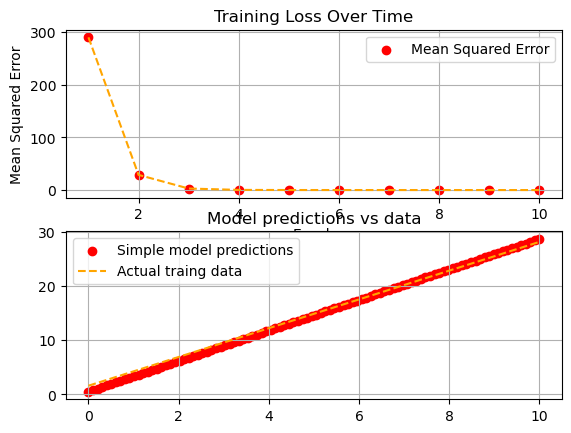

In [9]:
from matplotlib import pyplot as plt

model_preds = Simple.forward(inputs)

fig , axs = plt.subplots(2)

axs[0].scatter(x=time, y=mse_over_time, color='red', label='Mean Squared Error')
axs[0].plot(time, mse_over_time, color='orange', linestyle='--')

axs[0].set_title("Training Loss Over Time")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Mean Squared Error")
axs[0].grid(True)
axs[0].legend()


axs[1].scatter(x=x_axis_for_data, y=model_preds, color='red', label='Simple model predictions')
axs[1].plot(x_axis_for_data,  targets.flatten(), color='orange', linestyle='--', label='Actual traing data')

axs[1].set_title("Model predictions vs data")
axs[1].grid(True)
axs[1].legend()


plt.show()

### **MNIST** classifcation through gradient decent
In this section a sample of the MNIST dataset is used to show how a Model can be trained using this library. After a few itterations - to demonstrate the functionality of this library - a pretrained model (trained on a larger dataset using only this library) will be loaded to show of more accurate classifcaiton while saving time and compute.

#### Setting up the data

In [30]:
from pandas import read_csv
from pathlib import Path

data_dir = Path("reduced_MNIST_data")

data_frame = read_csv(data_dir)
data_frame = data_frame.drop(columns=["Unnamed: 0"], errors="ignore")

data = data_frame.to_numpy()
m, n = data.shape

data_dev = data[0:200]
Y_dev = data_dev[:, 0].astype(int)
X_dev = data_dev[:, 1:].astype(np.float32) / 255.0

data_train = data[200:m]
Y_train = data_train[:, 0].astype(int)
X_train = data_train[:, 1:].astype(np.float32) / 255.0

print(X_train.shape)
print(Y_train.shape)
m_train, n_features = X_train.shape

def one_hot(Y):
    Y = np.asarray(Y, dtype=int)
    one_hot_Y = np.zeros((Y.size, Y.max() + 1), dtype=np.float32)
    one_hot_Y[np.arange(Y.size), Y] = 1
    return one_hot_Y

Y_train = one_hot(Y_train)
Y_dev = one_hot(Y_dev)

print(X_train.shape)
print(Y_train.shape)

(800, 784)
(800,)
(800, 784)
(800, 10)


#### Creating and training a model

In [34]:
model = main.Model(input_size=784, output_size=10, hidden_size=64,
              number_of_layers=8, activation_function=main.ReLU, normalisation_function=main.Softmax,
              random_seed=11, initialisation_function="He")

In [ ]:
for i in range(100):
    output = model.forward(X_train)
    loss = main.CrossEntropyLoss(output, Y_train)
    model.backwards(output, Y_train, main.CrossEntropyLoss)
    model.update_parramaters(5e-2)
    if (i+1) % 10 == 0 or i == 0: 
        print(f"Epoch: {i+1}    Loss: {round(loss, 5)}    Accuracy: {round(np.exp(-loss) * 100, 3)}%")
        dev_output = model.forward(X_dev)
        dev_loss = main.CrossEntropyLoss(dev_output, Y_dev)
        print(f"Validation  loss: {round(dev_loss, 5)}    Accuracy: {round(np.exp(-dev_loss) * 100, 3)}%")

# Running just this cell again will continue training the existing model, training to 200 epochs.


Epoch: 1    Loss: 2.55345    Accuracy: 7.781%
Validation  loss: 2.35691    Accuracy: 9.471%
Epoch: 10    Loss: 2.08289    Accuracy: 12.457%
Validation  loss: 2.03503    Accuracy: 13.068%
Epoch: 20    Loss: 1.80689    Accuracy: 16.416%
Validation  loss: 1.83973    Accuracy: 15.886%
Epoch: 30    Loss: 1.48706    Accuracy: 22.604%
Validation  loss: 1.47744    Accuracy: 22.822%
Epoch: 40    Loss: 1.80238    Accuracy: 16.491%
Validation  loss: 1.3998    Accuracy: 24.665%
Epoch: 50    Loss: 1.00153    Accuracy: 36.732%
Validation  loss: 1.1018    Accuracy: 33.227%
Epoch: 60    Loss: 0.69871    Accuracy: 49.723%
Validation  loss: 0.82619    Accuracy: 43.771%
Epoch: 70    Loss: 0.76475    Accuracy: 46.545%
Validation  loss: 0.85563    Accuracy: 42.501%
Epoch: 80    Loss: 0.45577    Accuracy: 63.396%
Validation  loss: 0.64144    Accuracy: 52.654%
Epoch: 90    Loss: 0.53361    Accuracy: 58.649%
Validation  loss: 0.7125    Accuracy: 49.042%
Epoch: 100    Loss: 0.43235    Accuracy: 64.898%
Validat

#### Showcaseing the data from the model

In [40]:
print("Model parramaters for Layer 3:")
print(model.parramaters["Layer 3"])

print("Model gradients for Layer 3:")
print(model.gradients["Layer 3"])

Model parramaters for Layer 3:
{'weights': array([[ 0.00604448,  0.2403286 ,  0.21650493, ...,  0.13815235,
        -0.07775573, -0.0032215 ],
       [ 0.06060816, -0.16442744,  0.11351188, ...,  0.19630632,
         0.01817364,  0.17044196],
       [-0.07422657,  0.0633238 , -0.3706019 , ..., -0.1003093 ,
        -0.2033737 , -0.14825475],
       ...,
       [-0.01237789,  0.24530205, -0.14990601, ..., -0.11459492,
         0.15729558, -0.07823359],
       [-0.19577684,  0.3432112 ,  0.24594243, ..., -0.09618904,
         0.03912313, -0.19885333],
       [ 0.12761836, -0.11858875, -0.04611359, ..., -0.28454536,
         0.20866995,  0.05495067]], dtype=float32), 'biases': array([-0.217     , -0.5222485 ,  0.32019255,  0.19620852, -0.9693796 ,
       -0.41950056,  0.2328416 , -0.39372602,  0.91722775, -0.36888248,
       -0.8023296 ,  0.5643417 , -0.511736  , -0.858533  ,  0.06881265,
        0.9960808 , -0.3546356 , -0.6725177 , -0.08662074,  0.23945203,
        0.88740253, -0.536    

#### Loading a pretrianed model

In [42]:
from pickle import load
saved_model = main.Model(input_size=784, output_size=10, hidden_size=64,
              number_of_layers=8, activation_function=main.ReLU, normalisation_function=main.Softmax,
              random_seed=11, initialisation_function="He")

paramaters_path = Path("pretrained_model_parameters.pkl")

with paramaters_path.open("rb") as file:
    loaded_paramaters = load(file)

saved_model.set_parramaters(loaded_paramaters)
print("Retrived saved model")

Retrived saved model


In [43]:
# Displaying the saved model's loss and accuracy
# The training loss is found after all training ended and hard coded
print(f"Saved model's Training loss  : 0.05114    Training Accuracy  : 95.014% ")
output = saved_model.forward(X_dev)
loss = main.CrossEntropyLoss(output, Y_dev)
print(f"Saved model's Validation loss: {round(loss, 5)}    Validation Accuracy: {round(np.exp(-loss) * 100, 3)}% ")

Saved model's Training loss  : 0.05114    Training Accuracy  : 95.014% 
Saved model's Validation loss: 0.57842    Validation Accuracy: 56.079% 


#### Visual demonstration

Prediction: 4    Label: 4


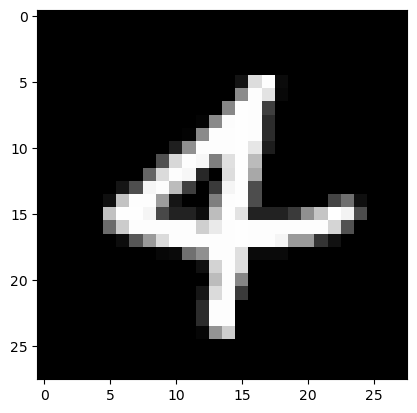

Prediction: 8    Label: 3


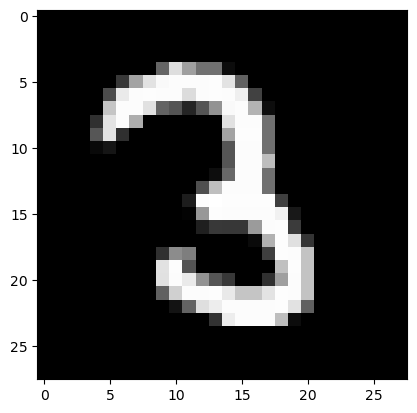

Prediction: 3    Label: 2


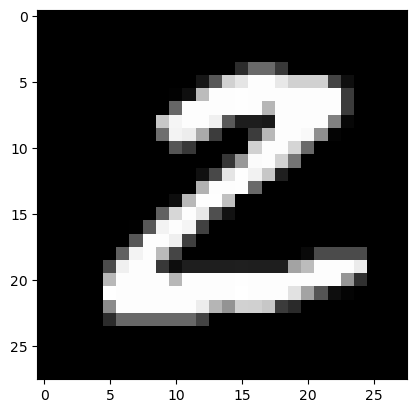

Prediction: 9    Label: 9


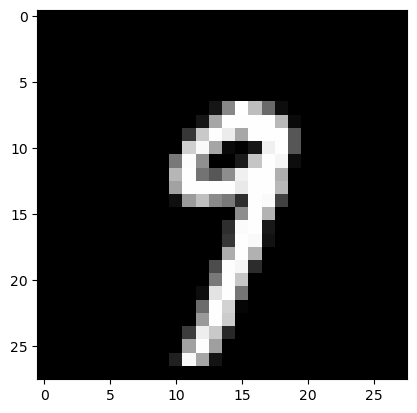

In [54]:
def show_prediction(index : int):
    current_image = X_dev[index:index + 1, None]
    probs = model.forward(current_image)
    prediction = np.argmax(probs)
    label = np.argmax(Y_dev[index])
    print(f"Prediction: {prediction}    Label: {label}")

    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()

for _ in range(4):
    index = np.random.randint(0, 199)
    show_prediction(index)

## Final thoughts

This libary is not very sophisticated or expansive, however the initial task of creating a system of interconecting functions has been done, and so it would take only a few minutes to add more componets such as:
- A wider variety of activation and normalisation functions
- Averaged gradients over time reducing the chance of being stuck at a local minimum
- Move initialisation functions for the LinearLayers
- etc

Regardless the aim of this project was to understand the maths behind gradient decent, not to create the best libary in existance, and that aim has been achived.

## Acknowledgements and Resources

A huge thanks to the following creators for their reasorces and explinations:

- 3Blue1Brown for all his videos, but particuarly the first 4 in his "Neural Networks" series.
    - https://www.youtube.com/playlist?list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi

- CodeEmporium for his "Back Propergation by hand" video.
    - https://www.youtube.com/watch?v=12-HUfbyGso&list=WL&index=4&t=1022s

- Samson Zhang for his tutorial "Building a neural network FROM SCRATCH" which fist introduced me to ML.
    - https://www.youtube.com/watch?v=w8yWXqWQYmU


As someone who taught temselves how to code, the folowing were very use full both in this project and others:

- Geeksforgeeks.org for their explinations with examples for python and common python libraries.
    - https://www.geeksforgeeks.org/

- As mentioned above, Ai tools such as Gemini and ChatGPT were used to explian errors, help with syntax and spot any bugs I may have missed. However, I made sure not to blindly use their code and **no** function was ever desined or fully created by anyone or anything other than myself.